In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv(r'C:\Users\junhyun111\Desktop\mf\mof_co2_vsa_lhs_100.csv')

In [ ]:
# 전처리용 복사본 생성
df_raw = df.copy()
df_clean = df.copy()

print(f'원본 데이터 크기: {df_raw.shape}')

원본 데이터 크기: (100, 13)


In [ ]:
# 결측치, 중복치, status 값
display(df_clean.isnull().sum().to_frame('missing_count').T)
print(f'중복 행 수: {df_clean.duplicated().sum()}')
print('status 분포:')
print(df_clean['status'].value_counts(dropna=False))

,sample_id,tADS,PL,v0,t_press,t_depress,CO2_purity,CO2_recovery,n_CO2_feed,n_CO2_product,n_N2_product,n_cycles,status
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0


중복 행 수: 0
status 분포:
status
ok    100
Name: count, dtype: int64


In [ ]:
# 분석에 쓰기 어려운 행을 제거
df_clean = df_clean.drop_duplicates().copy()
df_clean = df_clean[df_clean['status'].eq('ok')].copy()

# 핵심 수치 컬럼 기준으로 결측치를 제거
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
df_clean = df_clean.dropna(subset=numeric_cols).copy()

print(f'1차 정리 후 데이터 크기: {df_clean.shape}')

1차 정리 후 데이터 크기: (100, 13)


In [ ]:
# 물리적으로 말이 되지 않는 값은 제거
valid_mask = (
    (df_clean['tADS'] > 0) &
    (df_clean['PL'] > 0) &
    (df_clean['v0'] > 0) &
    (df_clean['t_press'] > 0) &
    (df_clean['t_depress'] > 0) &
    (df_clean['n_CO2_feed'] >= 0) &
    (df_clean['n_CO2_product'] >= 0) &
    (df_clean['n_N2_product'] >= 0) &
    (df_clean['CO2_purity'].between(0, 1)) &
    (df_clean['CO2_recovery'].between(0, 1))
)

removed_invalid = (~valid_mask).sum()
df_clean = df_clean.loc[valid_mask].copy()

print(f'비정상 범위 제거 행 수: {removed_invalid}')
print(f'범위 점검 후 데이터 크기: {df_clean.shape}')

비정상 범위 제거 행 수: 3
범위 점검 후 데이터 크기: (97, 13)


In [ ]:
# IQR 기준으로 이상치를 제거
outlier_cols = [
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'CO2_purity', 'CO2_recovery',
    'n_CO2_feed', 'n_CO2_product', 'n_N2_product'
]

Q1 = df_clean[outlier_cols].quantile(0.25)
Q3 = df_clean[outlier_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df_clean[outlier_cols] < (Q1 - 1.5 * IQR)) |
                (df_clean[outlier_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print(f'IQR 이상치 행 수: {outlier_mask.sum()}')
df_clean = df_clean.loc[~outlier_mask].copy()
print(f'최종 전처리 후 데이터 크기: {df_clean.shape}')

IQR 이상치 행 수: 9
최종 전처리 후 데이터 크기: (88, 13)


In [ ]:
# 이후 EDA에는 df_clean을 사용
display(df_clean.describe())
display(df_clean.head())

,sample_id,tADS,PL,v0,t_press,t_depress,CO2_purity,CO2_recovery,n_CO2_feed,n_CO2_product,n_N2_product,n_cycles
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.0
mean,49.727273,99.091696,0.363020,0.030175,37.807760,37.390630,0.374439,0.408942,0.082928,0.031174,0.051800,10.0
std,29.164112,34.938861,0.083132,0.011276,13.649641,12.767057,0.046852,0.134625,0.044889,0.014398,0.023795,0.0
min,1.000000,40.928747,0.201305,0.010378,15.077848,15.128043,0.298093,0.184485,0.011975,0.005189,0.011043,10.0
25%,24.750000,70.108690,0.296032,0.020436,25.875675,26.798065,0.337559,0.295508,0.052557,0.019349,0.031454,10.0
50%,48.500000,97.041984,0.368578,0.030056,38.047449,37.369111,0.366612,0.397778,0.070778,0.029602,0.048097,10.0
75%,73.250000,128.128036,0.432485,0.039900,49.933622,47.544037,0.400217,0.514720,0.110158,0.041620,0.066181,10.0
max,100.000000,159.954277,0.498181,0.049308,59.679703,59.820330,0.505429,0.751981,0.192994,0.070044,0.107978,10.0


,sample_id,tADS,PL,v0,t_press,t_depress,CO2_purity,CO2_recovery,n_CO2_feed,n_CO2_product,n_N2_product,n_cycles,status
0,1,105.646198,0.245723,0.021659,35.021980,49.664078,0.419087,0.504732,0.063276,0.031937,0.044270,10,ok
1,2,127.880727,0.476346,0.042095,19.664214,51.108738,0.325137,0.336564,0.148862,0.050102,0.103992,10,ok
2,3,148.182775,0.266589,0.047098,57.998897,22.002670,0.470062,0.216249,0.192994,0.041735,0.047051,10,ok
3,4,113.765315,0.316146,0.013809,55.851902,33.950220,0.381544,0.320301,0.043443,0.013915,0.022555,10,ok
4,5,85.872291,0.336466,0.014720,26.176337,45.568673,0.362815,0.460319,0.034954,0.016090,0.028258,10,ok


In [ ]:
# 입력변수와 출력변수를 따로 정의
input_cols = ['tADS', 'PL', 'v0', 't_press', 't_depress']
target_cols = ['CO2_purity', 'CO2_recovery']
eda_cols = input_cols + target_cols

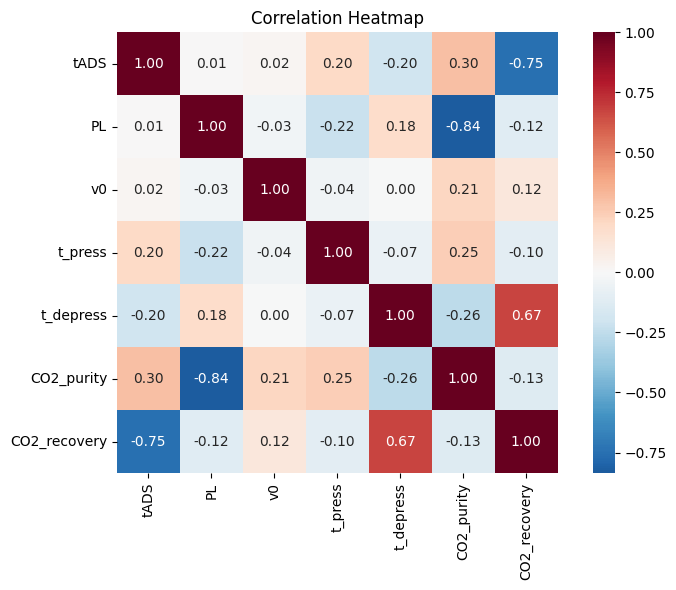

In [ ]:
# 입력변수와 출력변수 간 상관계수를 히트맵으로 확인
corr_matrix = df_clean[eda_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

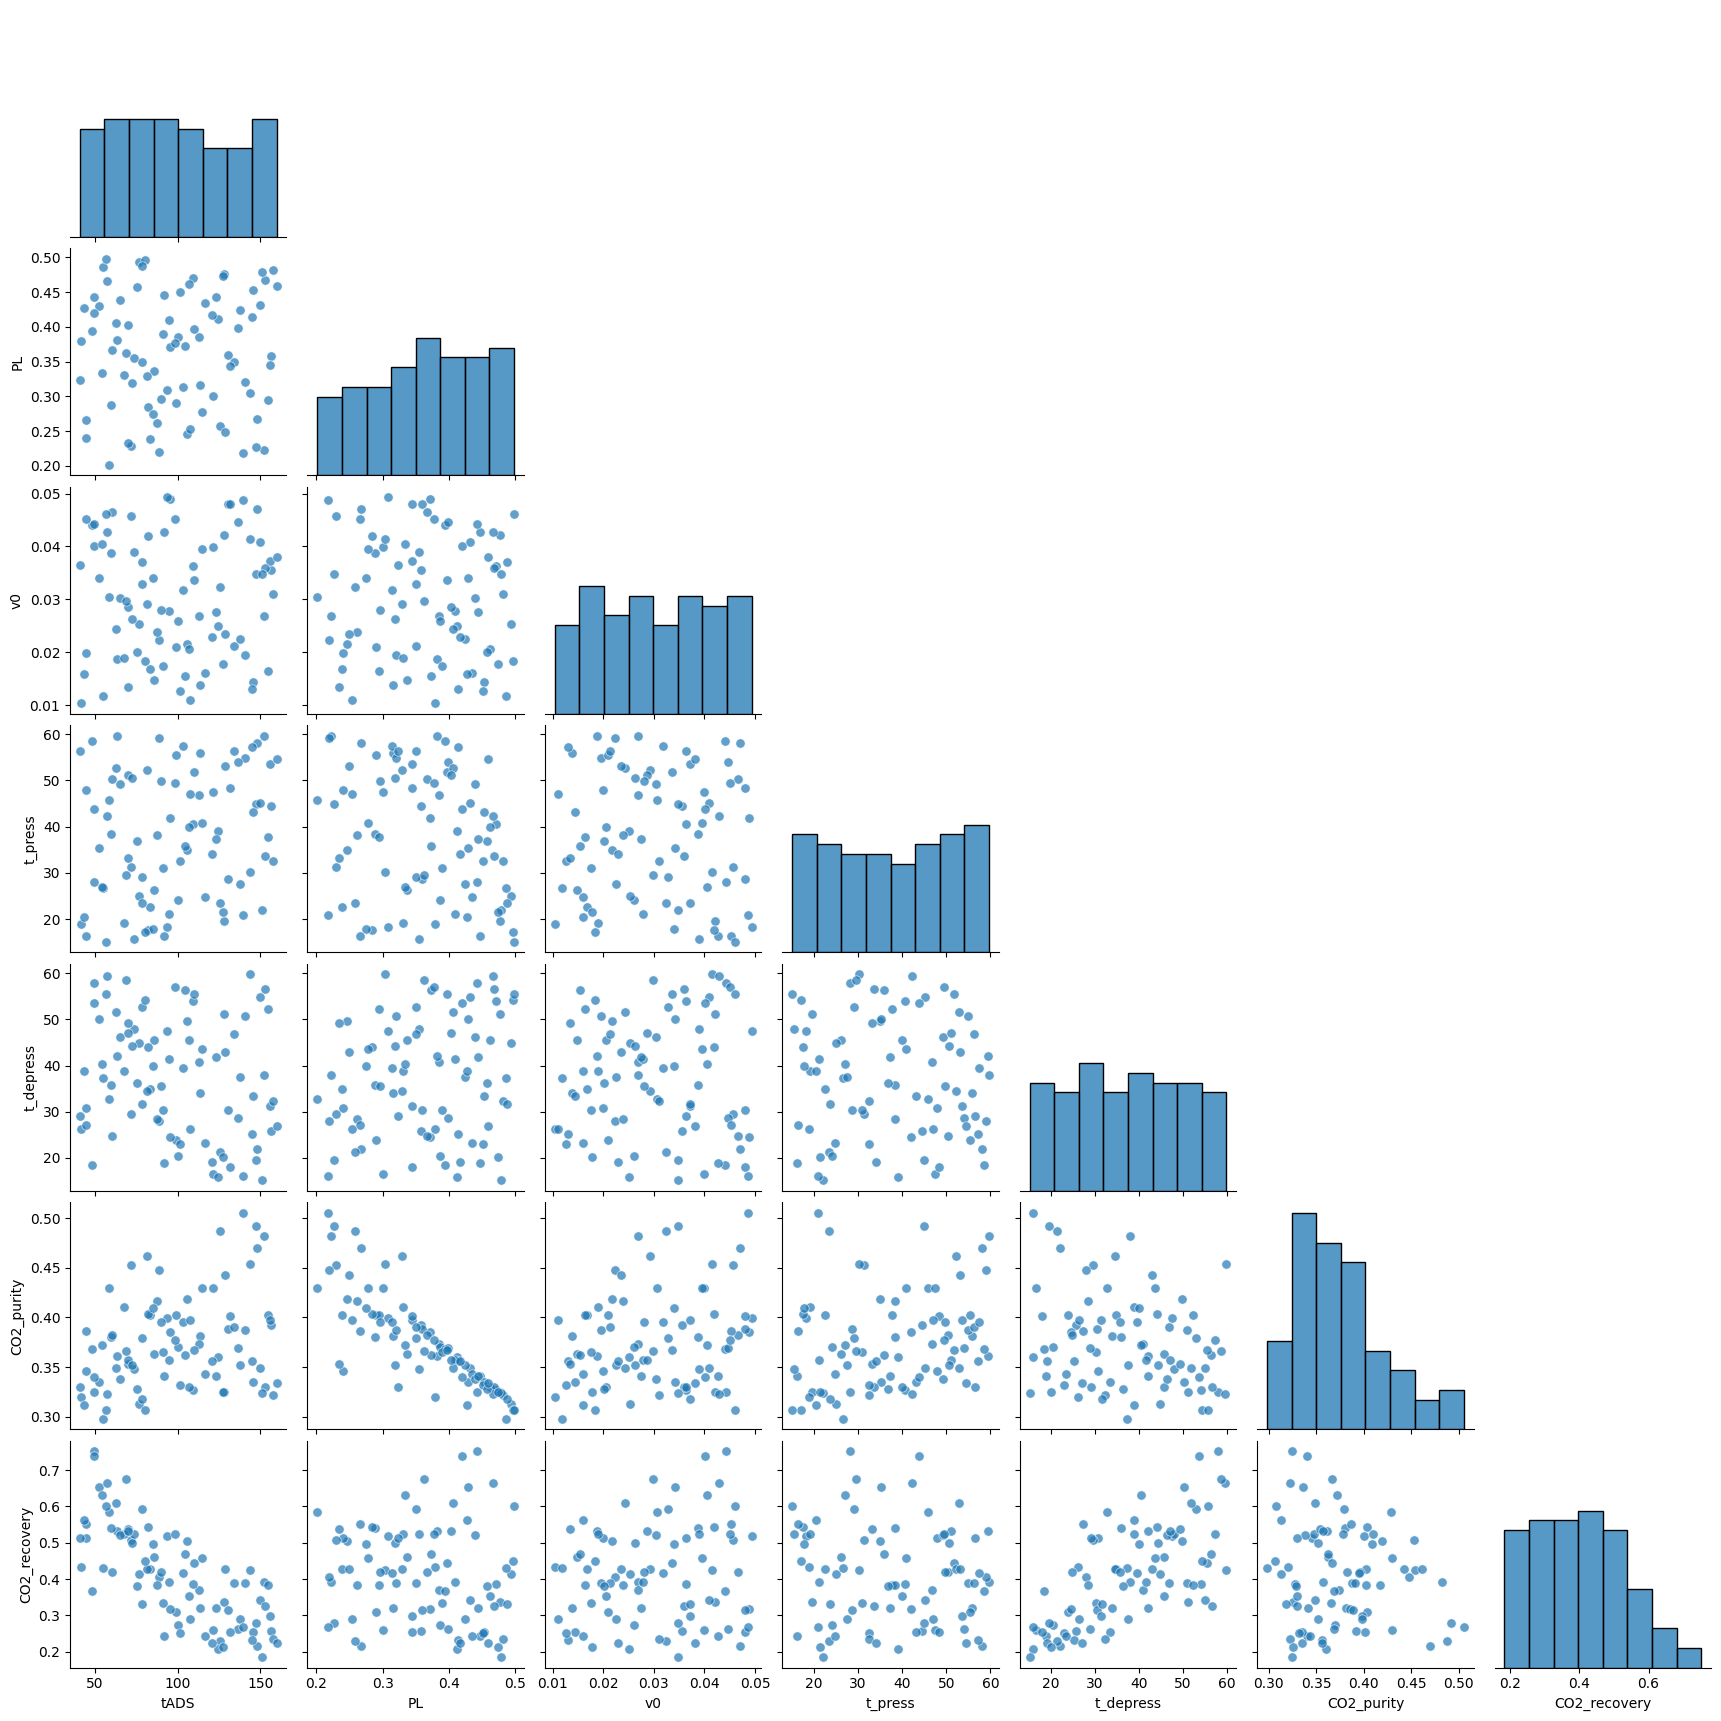

In [ ]:
# 변수 전체의 분포와 쌍별 관계를 pairplot으로 확인
sns.pairplot(
    df_clean[eda_cols],
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.7, 's': 45}
)
plt.show()

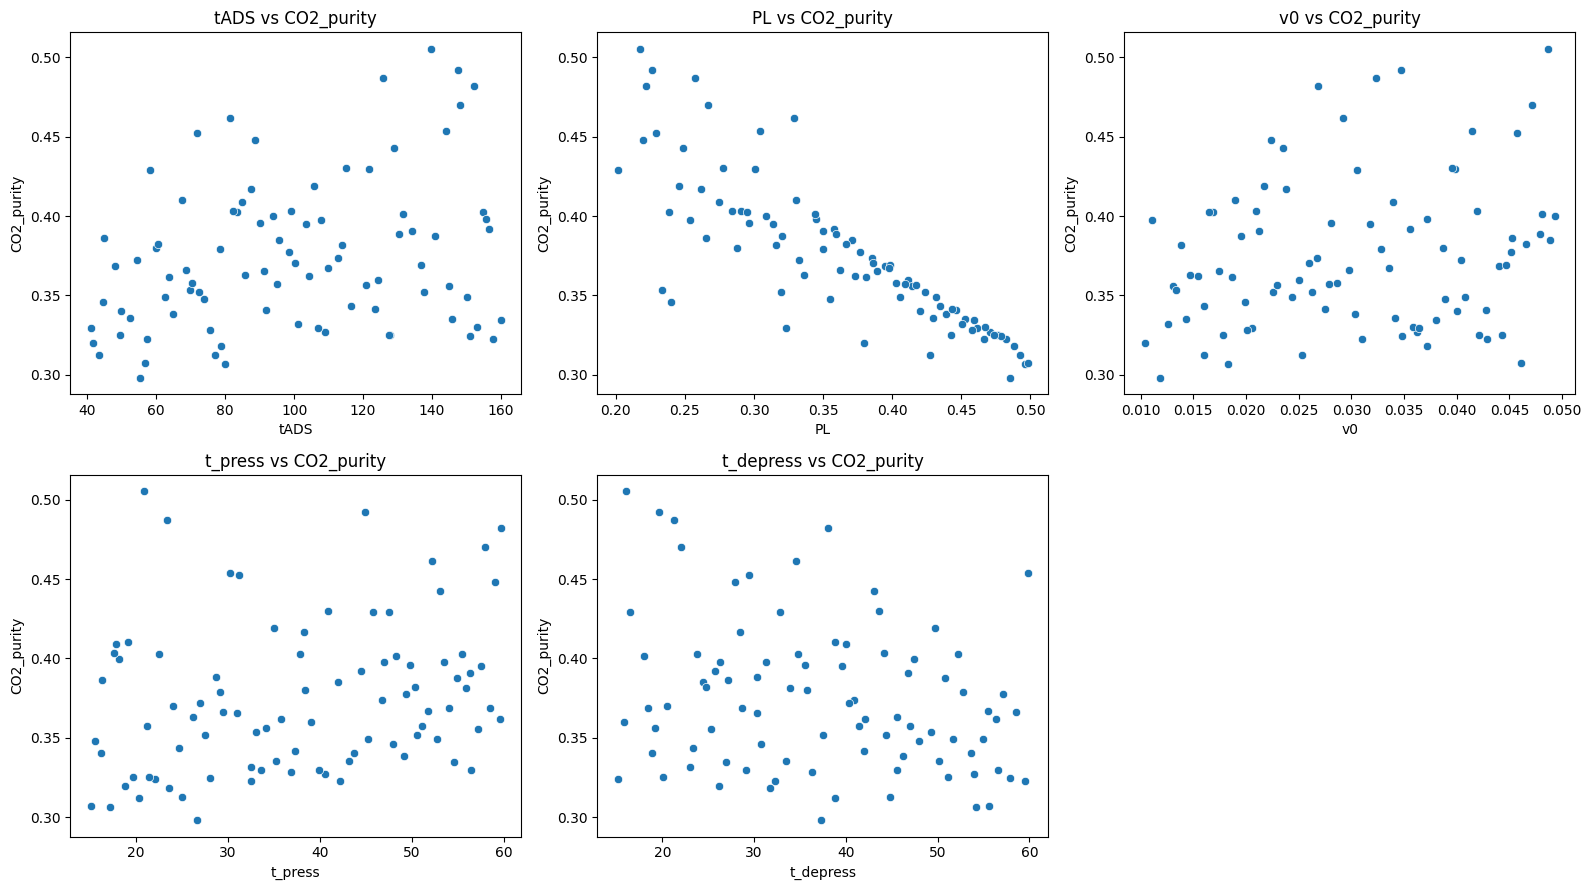

In [ ]:
# CO2_purity와 입력변수의 관계를 산점도로 확인
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(input_cols):
    sns.scatterplot(data=df_clean, x=col, y='CO2_purity', ax=axes[idx])
    axes[idx].set_title(f'{col} vs CO2_purity')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

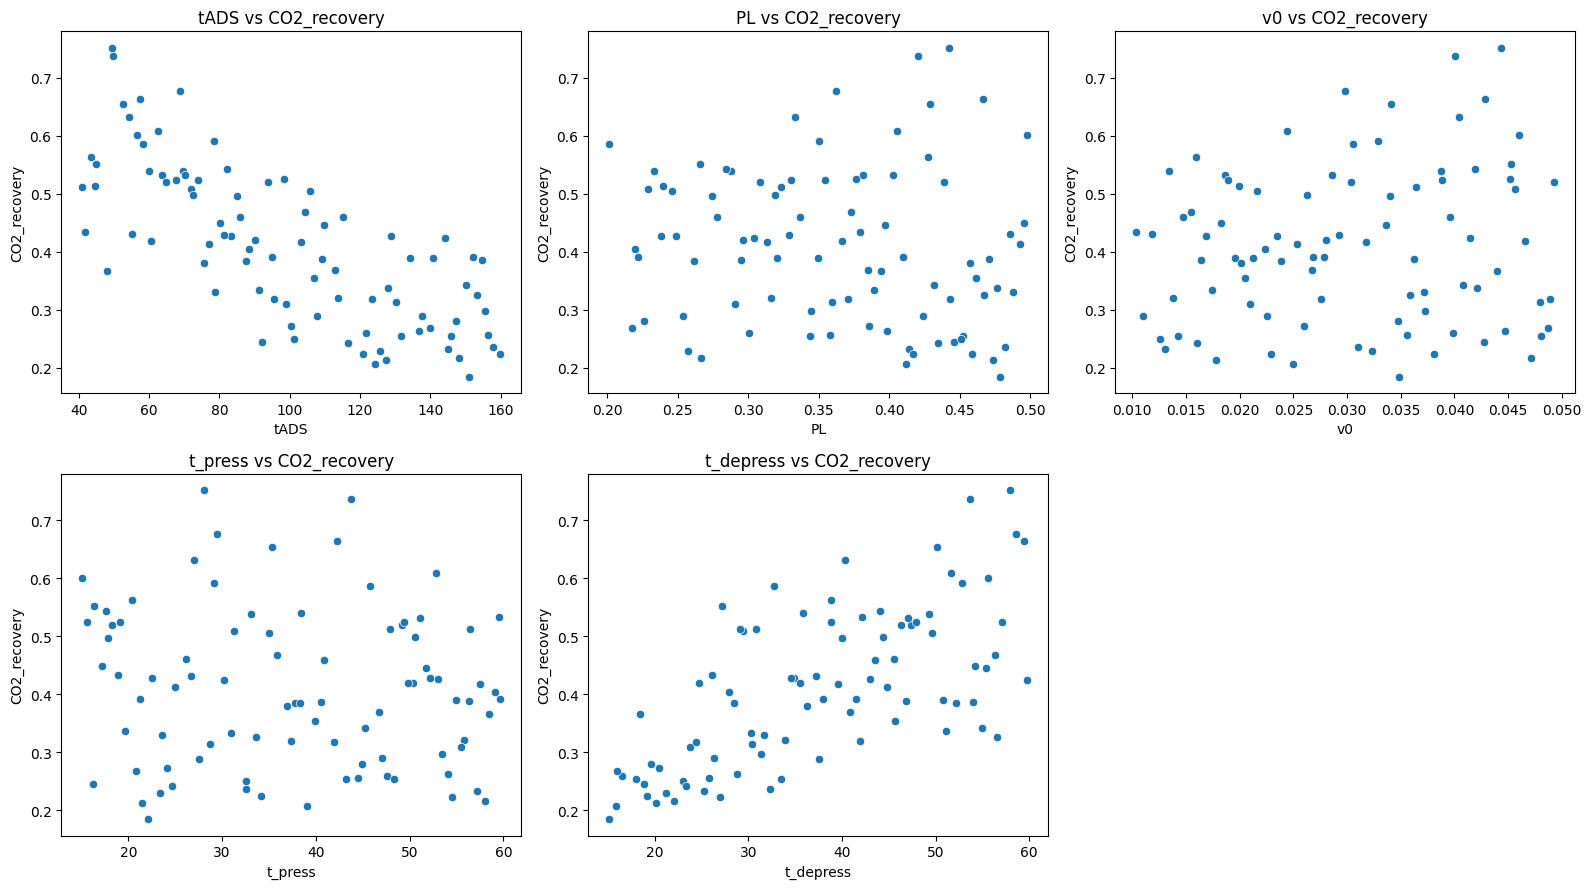

In [ ]:
# CO2_recovery와 입력변수의 관계를 산점도로 확인
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(input_cols):
    sns.scatterplot(data=df_clean, x=col, y='CO2_recovery', ax=axes[idx])
    axes[idx].set_title(f'{col} vs CO2_recovery')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [29]:
df_clean.to_csv("output.csv")